In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from statsbombpy import sb
from mplsoccer import Pitch, VerticalPitch

competitions= sb.competitions()

print(competitions.head())
print(competitions.columns)

   competition_id  season_id country_name        competition_name  \
0               9        281      Germany           1. Bundesliga   
1               9         27      Germany           1. Bundesliga   
2            1267        107       Africa  African Cup of Nations   
3              16          4       Europe        Champions League   
4              16          1       Europe        Champions League   

  competition_gender  competition_youth  competition_international  \
0               male              False                      False   
1               male              False                      False   
2               male              False                       True   
3               male              False                      False   
4               male              False                      False   

  season_name               match_updated           match_updated_360  \
0   2023/2024  2024-09-28T20:46:38.893391  2025-11-15T23:17:41.827093   
1   2015/2016  202

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from statsbombpy import sb
from mplsoccer import Pitch, VerticalPitch

competition_list= competitions[
    [
        "competition_id",
        "season_id",
        "country_name",
        "competition_name",
        "season_name"
    ]
]

print(competition_list.to_string())

    competition_id  season_id               country_name         competition_name season_name
0                9        281                    Germany            1. Bundesliga   2023/2024
1                9         27                    Germany            1. Bundesliga   2015/2016
2             1267        107                     Africa   African Cup of Nations        2023
3               16          4                     Europe         Champions League   2018/2019
4               16          1                     Europe         Champions League   2017/2018
5               16          2                     Europe         Champions League   2016/2017
6               16         27                     Europe         Champions League   2015/2016
7               16         26                     Europe         Champions League   2014/2015
8               16         25                     Europe         Champions League   2013/2014
9               16         24                     Europe    

In [11]:
world_cup=competitions[
    competitions["competition_name"].str.contains(
        "World cup",
        case=False,
        na=False
    )
]

world_cup[
    [
        "competition_id",
        "season_id",
        "competition_name",
        "season_name"
    ]
]

,competition_id,season_id,competition_name,season_name
29,1470,274,FIFA U20 World Cup,1979
30,43,106,FIFA World Cup,2022
31,43,3,FIFA World Cup,2018
32,43,55,FIFA World Cup,1990
33,43,54,FIFA World Cup,1986
34,43,51,FIFA World Cup,1974
35,43,272,FIFA World Cup,1970
36,43,270,FIFA World Cup,1962
37,43,269,FIFA World Cup,1958
78,72,107,Women's World Cup,2023


In [20]:
champions_league = competitions[
    competitions["competition_name"].str.contains(
        "Champions League",
        case=False,
        na=False
    )
]

champions_league[
    [
        "competition_id",
        "season_id",
        "competition_name",
        "season_name"
    ]
]

,competition_id,season_id,competition_name,season_name
3,16,4,Champions League,2018/2019
4,16,1,Champions League,2017/2018
5,16,2,Champions League,2016/2017
6,16,27,Champions League,2015/2016
7,16,26,Champions League,2014/2015
8,16,25,Champions League,2013/2014
9,16,24,Champions League,2012/2013
10,16,23,Champions League,2011/2012
11,16,22,Champions League,2010/2011
12,16,21,Champions League,2009/2010


In [26]:
matches = sb.matches(
    competition_id=43,
    season_id=106
)

matches[
    [
        "match_id",
        "match_date",
        "home_team",
        "away_team",
        "home_score",
        "away_score"
    ]
].head()

,match_id,match_date,home_team,away_team,home_score,away_score
0,3857276,2022-12-01,Canada,Morocco,1,2
1,3857271,2022-11-21,England,Iran,6,2
2,3857296,2022-12-01,Croatia,Belgium,0,0
3,3857274,2022-11-25,Netherlands,Ecuador,1,1
4,3857255,2022-12-01,Japan,Spain,2,1


In [27]:
korea_matches = matches[
    matches["home_team"].str.contains(
        "Korea",
        case=False,
        na=False
    )
    |
    matches["away_team"].str.contains(
        "Korea",
        case=False,
        na=False
    )
]

korea_matches[
    [
        "match_id",
        "match_date",
        "home_team",
        "away_team",
        "home_score",
        "away_score"
    ]
]

,match_id,match_date,home_team,away_team,home_score,away_score
35,3857287,2022-11-24,Uruguay,South Korea,0,0
48,3869253,2022-12-05,Brazil,South Korea,4,1
57,3857299,2022-11-28,South Korea,Ghana,2,3
63,3857262,2022-12-02,South Korea,Portugal,2,1


In [28]:
selected_match = korea_matches.iloc[0]

match_id = int(selected_match["match_id"])
home_team = selected_match["home_team"]
away_team = selected_match["away_team"]

print("match_id:", match_id)
print("경기:", home_team, "vs", away_team)

match_id: 3857287
경기: Uruguay vs South Korea


In [30]:
korea_matches.to_csv(
    "korea_world_cup_matches.csv",
    index=False,
    encoding="utf-8-sig"
)

In [2]:
from statsbombpy import sb

match_id=3857287

events = sb.events(match_id=match_id)

print(events.head())
print(events.shape)

C:\Users\박경빈\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


  ball_receipt_outcome ball_recovery_recovery_failure block_offensive  \
0                  NaN                            NaN             NaN   
1                  NaN                            NaN             NaN   
2                  NaN                            NaN             NaN   
3                  NaN                            NaN             NaN   
4                  NaN                            NaN             NaN   

  carry_end_location clearance_aerial_won clearance_body_part clearance_head  \
0                NaN                  NaN                 NaN            NaN   
1                NaN                  NaN                 NaN            NaN   
2                NaN                  NaN                 NaN            NaN   
3                NaN                  NaN                 NaN            NaN   
4                NaN                  NaN                 NaN            NaN   

  clearance_left_foot clearance_right_foot counterpress  ...  \
0               

In [3]:
print(events.columns.tolist())

['ball_receipt_outcome', 'ball_recovery_recovery_failure', 'block_offensive', 'carry_end_location', 'clearance_aerial_won', 'clearance_body_part', 'clearance_head', 'clearance_left_foot', 'clearance_right_foot', 'counterpress', 'dribble_outcome', 'dribble_overrun', 'duel_outcome', 'duel_type', 'duration', 'foul_committed_advantage', 'foul_committed_card', 'foul_committed_offensive', 'foul_committed_type', 'foul_won_advantage', 'foul_won_defensive', 'goalkeeper_body_part', 'goalkeeper_end_location', 'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique', 'goalkeeper_type', 'id', 'index', 'injury_stoppage_in_chain', 'interception_outcome', 'location', 'match_id', 'minute', 'miscontrol_aerial_won', 'off_camera', 'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id', 'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_deflected', 'pass_end_location', 'pass_height', 'pass_inswinging', 'pass_length', 'pass_outcome', 'pass_outswinging', 'pass_recipient', 'pass_recipi

In [4]:
main_event_types = [
    "Pass",
    "Shot",
    "Pressure",
    "Carry",
    "Dribble",
    "Interception",
    "Ball Recovery"
]

main_event_counts = (
    events[
        events["type"].isin(main_event_types)
    ]
    ["type"]
    .value_counts()
    .reset_index()
)

main_event_counts.columns = ["event_type", "count"]

main_event_counts

,event_type,count
0,Pass,1033
1,Carry,812
2,Pressure,205
3,Ball Recovery,79
4,Interception,30
5,Dribble,27
6,Shot,17


In [5]:
passes = events[
    events["type"] == "Pass"
].copy()

shots = events[
    events["type"] == "Shot"
].copy()

pressures = events[
    events["type"] == "Pressure"
].copy()

print("패스 수:", len(passes))
print("슈팅 수:", len(shots))
print("압박 수:", len(pressures))

패스 수: 1033
슈팅 수: 17
압박 수: 205


In [8]:
team_event_counts = (
    events
    .groupby(["team", "type"])
    .size()
    .reset_index(name="count")
)

team_event_counts[
    team_event_counts["type"].isin(
        ["Pass", "Shot", "Pressure"]
    )
]

,team,type,count
17,South Korea,Pass,463
20,South Korea,Pressure,103
22,South Korea,Shot,7
43,Uruguay,Pass,570
44,Uruguay,Pressure,102
46,Uruguay,Shot,10


In [9]:
shot_columns = [
    "team",
    "player",
    "minute",
    "location",
    "shot_outcome",
    "shot_statsbomb_xg"
]

shots[shot_columns].head()

,team,player,minute,location,shot_outcome,shot_statsbomb_xg
3423,Uruguay,Matías Vecino Falero,12,"[109.5, 28.6]",Saved,0.052239
3424,Uruguay,Federico Santiago Valverde Dipetta,18,"[103.9, 35.4]",Off T,0.051877
3425,South Korea,Ui-Jo Hwang,33,"[108.9, 42.7]",Off T,0.323128
3426,South Korea,In-Beom Hwang,38,"[89.7, 57.6]",Off T,0.007071
3427,Uruguay,Diego Roberto Godín Leal,42,"[110.0, 40.4]",Post,0.054689


In [10]:
pass_columns = [
    "team",
    "player",
    "minute",
    "location",
    "pass_end_location",
    "pass_outcome"
]

passes[pass_columns].head()

,team,player,minute,location,pass_end_location,pass_outcome
6,South Korea,Ui-Jo Hwang,0,"[60.0, 40.0]","[40.6, 39.5]",NaN
7,South Korea,Woo-Young Jung,0,"[41.5, 38.5]","[33.4, 19.9]",NaN
8,South Korea,Young-Gwon Kim,0,"[36.3, 17.1]","[95.0, 64.2]",NaN
9,Uruguay,Matías Vecino Falero,0,"[29.2, 23.5]","[25.8, 24.6]",NaN
10,Uruguay,Rodrigo Bentancur Colmán,0,"[25.4, 23.1]","[28.2, 12.8]",NaN


In [11]:
events.to_csv(
    "selected_match_events.csv",
    index=False,
    encoding="utf-8-sig"
)

In [4]:
from statsbombpy import sb

match_id=3857287

events=sb.events(match_id=match_id)

print(events.shape)

shots = events[
    events["type"] == "Shot"
].copy()

C:\Users\박경빈\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


(3462, 87)


In [8]:
korea_shots = shots[
    shots["team"] == "South Korea"
].copy()

print("전체 슈팅:", shots.shape)
print("한국 슈팅:", korea_shots.shape)
korea_shots[
    [
        "player",
        "minute",
        "location",
        "shot_outcome",
        "shot_statsbomb_xg"
    ]
]

전체 슈팅: (17, 87)
한국 슈팅: (7, 87)


,player,minute,location,shot_outcome,shot_statsbomb_xg
3425,Ui-Jo Hwang,33,"[108.9, 42.7]",Off T,0.323128
3426,In-Beom Hwang,38,"[89.7, 57.6]",Off T,0.007071
3429,Min Jae Kim,52,"[111.5, 46.1]",Wayward,0.046898
3433,Kang-In Lee,74,"[94.5, 54.2]",Blocked,0.023163
3434,Gue-Sung Cho,76,"[93.4, 42.0]",Off T,0.036146
3438,Heung-Min Son,89,"[93.8, 36.6]",Off T,0.033557
3439,In-Beom Hwang,93,"[94.9, 26.7]",Off T,0.023030


In [9]:
korea_shots["x"] = korea_shots["location"].str[0]
korea_shots["y"] = korea_shots["location"].str[1]

korea_shots[
    ["player", "x", "y", "shot_statsbomb_xg", "shot_outcome"]
]

,player,x,y,shot_statsbomb_xg,shot_outcome
3425,Ui-Jo Hwang,108.9,42.7,0.323128,Off T
3426,In-Beom Hwang,89.7,57.6,0.007071,Off T
3429,Min Jae Kim,111.5,46.1,0.046898,Wayward
3433,Kang-In Lee,94.5,54.2,0.023163,Blocked
3434,Gue-Sung Cho,93.4,42.0,0.036146,Off T
3438,Heung-Min Son,93.8,36.6,0.033557,Off T
3439,In-Beom Hwang,94.9,26.7,0.023030,Off T


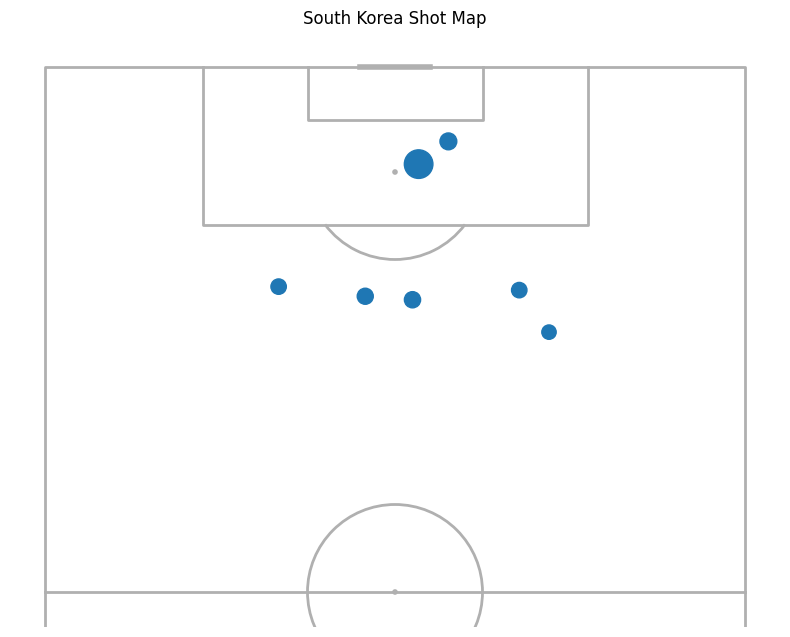

In [11]:
from mplsoccer import VerticalPitch
import matplotlib.pyplot as plt

pitch = VerticalPitch(
    pitch_type="statsbomb",
    half=True
)

fig, ax = pitch.draw(figsize=(8, 10))

pitch.scatter(
    korea_shots["x"],
    korea_shots["y"],
    s=korea_shots["shot_statsbomb_xg"] * 1000 + 100,
    ax=ax
)

plt.title("South Korea Shot Map")
plt.show()

In [12]:
passes = events[
    events["type"] == "Pass"
].copy()

korea_passes = passes[
    passes["team"] == "South Korea"
].copy()

successful_passes = korea_passes[
    korea_passes["pass_outcome"].isna()
].copy()

successful_passes = successful_passes.dropna(
    subset=["location", "pass_end_location"]
)

successful_passes["x"] = successful_passes["location"].str[0]
successful_passes["y"] = successful_passes["location"].str[1]

successful_passes["end_x"] = successful_passes["pass_end_location"].str[0]
successful_passes["end_y"] = successful_passes["pass_end_location"].str[1]

successful_passes[
    [
        "player",
        "x",
        "y",
        "end_x",
        "end_y"
    ]
].head()

,player,x,y,end_x,end_y
6,Ui-Jo Hwang,60.0,40.0,40.6,39.5
7,Woo-Young Jung,41.5,38.5,33.4,19.9
8,Young-Gwon Kim,36.3,17.1,95.0,64.2
14,Min Jae Kim,68.6,64.5,48.8,42.9
15,Young-Gwon Kim,48.8,41.6,47.5,60.7


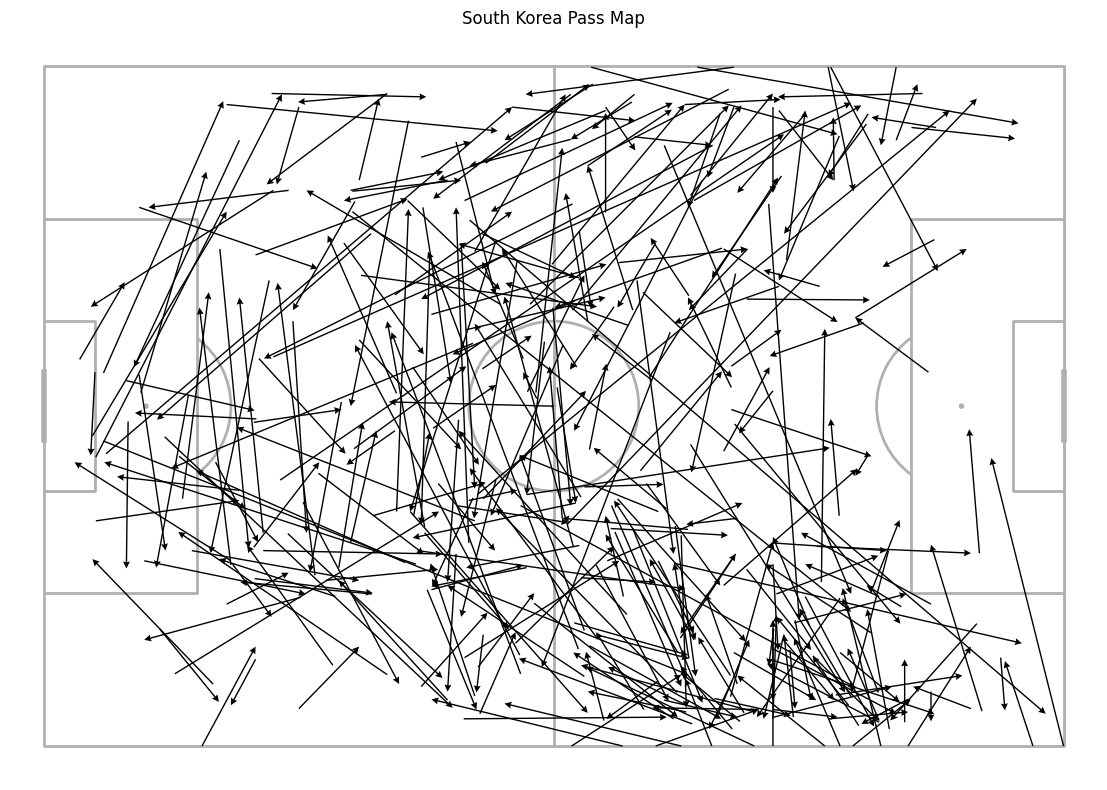

In [13]:
from mplsoccer import Pitch

pitch = Pitch(
    pitch_type="statsbomb"
)

fig, ax = pitch.draw(figsize=(12, 8))

pitch.arrows(
    successful_passes["x"],
    successful_passes["y"],
    successful_passes["end_x"],
    successful_passes["end_y"],
    width=1,
    headwidth=5,
    ax=ax
)

plt.title("South Korea Pass Map")
plt.show()

In [14]:
korea_passes["player"].value_counts().head(10)

player
Moon-Hwan Kim     63
In-Beom Hwang     62
Woo-Young Jung    57
Min Jae Kim       52
Young-Gwon Kim    43
Jae-Sung Lee      35
Seung-Gyu Kim     33
Heung-Min Son     30
Jin-Su Kim        29
Sang-Ho Na        22
Name: count, dtype: int64

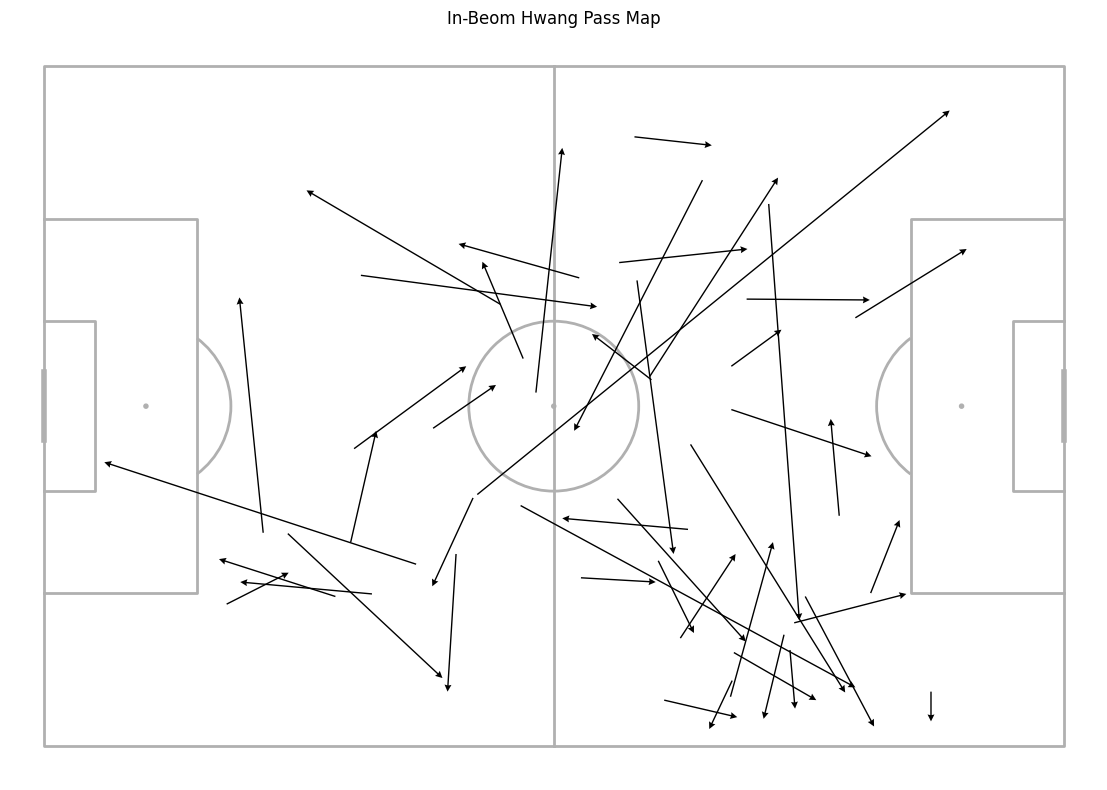

In [16]:
player_name = "In-Beom Hwang"

player_passes = successful_passes[
    successful_passes["player"] == player_name
].copy()

fig, ax = pitch.draw(figsize=(12, 8))

pitch.arrows(
    player_passes["x"],
    player_passes["y"],
    player_passes["end_x"],
    player_passes["end_y"],
    width=1,
    headwidth=5,
    ax=ax
)

plt.title(f"{player_name} Pass Map")
plt.show()

In [17]:
korea_events = events[
    events["team"] == "South Korea"
].copy()

korea_events["player"].value_counts().head(10)

player
In-Beom Hwang     204
Woo-Young Jung    176
Moon-Hwan Kim     169
Min Jae Kim       146
Jae-Sung Lee      132
Heung-Min Son     128
Sang-Ho Na        127
Young-Gwon Kim    125
Jin-Su Kim         86
Seung-Gyu Kim      78
Name: count, dtype: int64

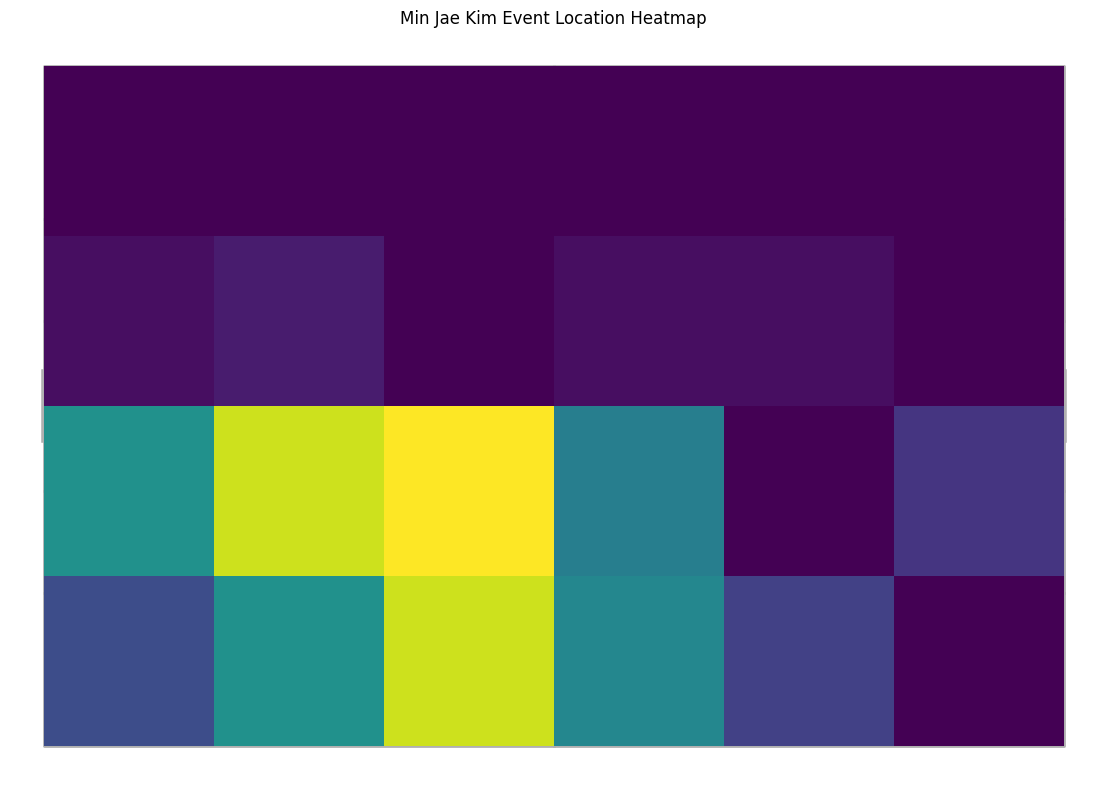

In [6]:
from statsbombpy import sb

match_id=3857287

events=sb.events(match_id=match_id)

korea_events = events[
    events["team"] == "South Korea"
].copy()

player_name = "Min Jae Kim"

player_events = korea_events[
    korea_events["player"] == player_name
].copy()

player_events = player_events.dropna(
    subset=["location"]
)

player_events["x"] = player_events["location"].str[0]
player_events["y"] = player_events["location"].str[1]

from mplsoccer import Pitch
import matplotlib.pyplot as plt

pitch = Pitch(
    pitch_type="statsbomb"
)

fig, ax = pitch.draw(figsize=(12, 8))

bin_statistic = pitch.bin_statistic(
    player_events["x"],
    player_events["y"],
    statistic="count",
    bins=(6, 4)
)

pitch.heatmap(
    bin_statistic,
    ax=ax
)

plt.title(f"{player_name} Event Location Heatmap")
plt.show()